# DL Foundations: Convolutional Neural Networks in CV. Part 3.

# Loss & Metrics

В задачах компьютерного зрения выбор **loss** для обучения и **метрики** для оценки модели играет ключевую роль.  

Ключевые моменты:  
- Binary vs multi-class vs multi-label classification 
- Class imbalance (несбалансированные классы)   
- Numerical stability (численная стабильность)

## 1. Loss Functions

#### 1. Binary Cross-Entropy (BCE)
**Проблема:** бинарная классификация и multi-label задачи требуют корректной оценки вероятности для каждого класса.  

**Формула:**  
$$
\text{BCE}(y, \hat{y}) = - \frac{1}{N} \sum_{i=1}^N \left[ y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i) \right]
$$

**Особенности и плюсы/минусы:**  
- [+] Хорошо подходит для бинарных задач и multilabel  
- [+] Можно использовать `BCEWithLogitsLoss` (устраняет численную нестабильность)  
- [-] Чувствителен к сильно несбалансированным классам  

---

#### 2. Cross-Entropy (CE)
**Проблема:** multiclass задачи требуют предсказания одного класса среди многих, где классы взаимоисключающие.  

**Формула:**  
$$
\text{CE}(y, \hat{y}) = - \sum_{c=1}^{C} y_c \log \hat{y}_c
$$

**Особенности и численная стабильность:**  
- Softmax:  
$$
\hat{y}_c = \frac{e^{z_c}}{\sum_{k} e^{z_k}}
$$
- При больших значениях $z_c$ возможны **overflow / underflow**  
- **Решение:** log-sum-exp trick  
$$
\log \sum_i e^{z_i} = m + \log \sum_i e^{z_i - m}, \quad m = \max_i z_i
$$
- В PyTorch уже реализовано внутри `CrossEntropyLoss`, поэтому вручную трюк применять не нужно.

**Плюсы/минусы:**  
- [+] Подходит для mutually exclusive классов  
- [+] Встроенный softmax + log-sum-exp  
- [-] Не подходит для multilabel задач  

---

#### 3. Focal Loss
**Проблема:** class imbalance, когда модель слишком фокусируется на frequent classes и игнорирует редкие.  

**Формула:**  
$$
\text{FL}(p_t) = - \alpha (1 - p_t)^\gamma \log(p_t)
$$

**Плюсы/минусы:**  
- [+] Фокус на hard examples  
- [+] Улучшает обучение при редких классах  
- [-] Нужно подбирать $\alpha$ и $\gamma$ 
- [-] Может замедлять обучение на сбалансированных датасетах  

---

#### 4. L1 / L2 Regularization
**Проблема:** сложные модели с большим числом параметров склонны к **overfitting**. Регуляризация добавляет штраф за большие веса.  

- **L2 (weight decay / Ridge)**:  
$$
\text{Loss}_{total} = \text{Loss}_{task} + \lambda \sum_i w_i^2
$$

- **L1 (Lasso)**:  
$$
\text{Loss}_{total} = \text{Loss}_{task} + \lambda \sum_i |w_i|
$$

**Особенности и плюсы/минусы:**  
| Регуляризация | Плюсы | Минусы | Комментарий |
|---------------|-------|--------|-------------|
| **L2** | Снижает веса, предотвращает overfitting, стабильно работает с SGD/Adam | Редко обнуляет веса полностью | Чаще используется как default weight decay |
| **L1** | Может приводить к разреженности весов (feature selection), убирает ненужные признаки | Менее стабильна при оптимизации, чувствительна к learning rate | Полезна для высокоразмерных данных и sparse features |



## 2. Metrics

#### 1. Precision, Recall, F1

Для задач классификации, особенно при несбалансированных классах:

$$
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}, \quad
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Где:  
- **TP** — true positives (правильно предсказанные положительные)  
- **FP** — false positives (ошибочно предсказанные положительные)  
- **FN** — false negatives (пропущенные положительные)  

**Примечания:**  
- Precision показывает “насколько предсказания положительных правильны”  
- Recall показывает “сколько реальных положительных мы нашли”  
- F1 — гармоническое среднее между Precision и Recall  

**Плюсы / Минусы:**  
- [+] Подходит для несбалансированных классов  
- [+] F1 балансирует Precision и Recall  
- [-] Не учитывает TN, может быть неинформативна при очень редких классах  

---

#### 4. ROC-AUC
- **Что измеряет:** способность модели различать положительный и отрицательный класс по всем порогам  
- **Формула (бинарная):** площадь под ROC-кривой, где ROC = TPR vs FPR  

**Плюсы / Минусы:**  
- [+] Устойчива к несбалансированным классам  
- [+] Можно использовать для multilabel задачи  
- [-] Для multiclass нужна усреднённая версия (macro/micro)  
- [-] Не отражает точность на конкретном пороге
_____

#### 2. Accuracy

Простая метрика: доля правильных предсказаний.  

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- [+] Простая, интуитивно понятная метрика  
- [-] Не подходит для сильно несбалансированных классов  



## 3. Multiclass vs Multilabel

### Multiclass
- Каждый объект принадлежит **только одному классу**   
- Loss: **softmax + CrossEntropyLoss**  

### Multilabel
- Объект может принадлежать **нескольким классам одновременно**  
- Метрики вычисляются для каждого класса отдельно и усредняются  
- Loss: **sigmoid + BCEWithLogitsLoss**  

**Пример усреднения F1:**  
- **Macro F1:** среднее по классам, не учитывает частоту  
- **Micro F1:** глобальный подсчет TP/FP/FN, учитывает частоту  

---

## 4. Практические советы

- Использовать **precision/recall/F1** для несбалансированных классов  
- Для multiclass: часто считают **macro/micro F1**  
- Для multilabel: считать метрики по каждому классу и усреднять  
- Для бинарной классификации: confusion matrix помогает визуализировать ошибки  

Binary BCE Loss: 0.36600354313850403
Focal Loss: 0.09162967652082443
Accuracy: 0.860
Precision: 0.167
Recall: 0.100
F1 Score: 0.125


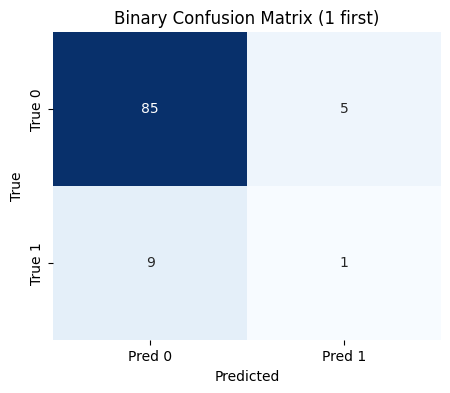

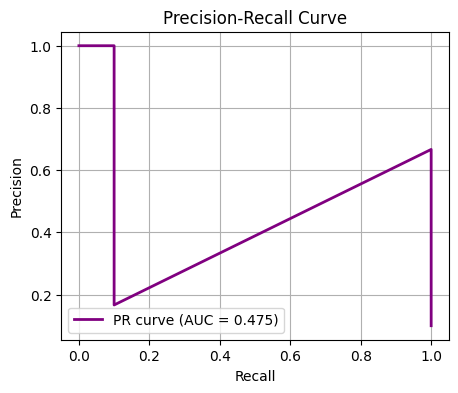

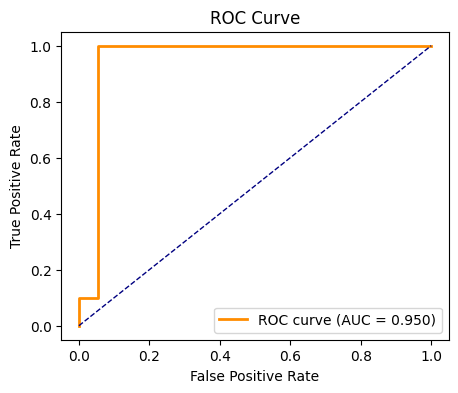

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             accuracy_score, roc_auc_score, confusion_matrix, 
                             roc_curve, auc, precision_recall_curve)

# Несбалансированные данные
y_true = torch.tensor([0]*90 + [1]*10)  # 100 примеров: 90 нулей, 10 единиц

# Логиты модели: отрицательные для 0, положительные для 1, большие ошибки для редких
y_pred_logits = torch.tensor([-1.5]*85 + [2.0]*5 + [-0.5]*9 + [2.5]*1)

# BCE Loss
bce_loss_fn = nn.BCEWithLogitsLoss()
bce_loss = bce_loss_fn(y_pred_logits.float(), y_true.float())
print("Binary BCE Loss:", bce_loss.item())

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0) -> None:
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets.float(), reduction='none')
        probas = torch.sigmoid(logits)
        pt = torch.where(targets==1, probas, 1-probas)
        loss = self.alpha * (1-pt)**self.gamma * bce
        return loss.mean()

focal_loss_fn = FocalLoss()
focal_loss = focal_loss_fn(y_pred_logits, y_true)
print("Focal Loss:", focal_loss.item())

# Predictions and Metrics
y_prob = torch.sigmoid(y_pred_logits).detach().cpu().numpy()
y_pred = (y_prob >= 0.5).astype(int)
y_true_np = y_true.numpy()

acc = accuracy_score(y_true_np, y_pred)
prec = precision_score(y_true_np, y_pred, zero_division=0)
rec = recall_score(y_true_np, y_pred, zero_division=0)
f1 = f1_score(y_true_np, y_pred, zero_division=0)

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1 Score: {f1:.3f}")


# Confusion Matrix
cm = confusion_matrix(y_true_np, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'],
            cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Binary Confusion Matrix (1 first)")
plt.show()

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, y_prob)
pr_auc = auc(recall, precision)
plt.figure(figsize=(5,4))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true_np, y_prob)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Файнтюннинг CNN

Файнтюннинг (*fine-tuning*) — это процесс **дополнительного обучения предобученной модели** на новой задаче.  
Основная идея:

- Используем модель, обученную на большой выборке
- Сохраняем веса, чтобы использовать уже изученные признаки
- Дообучаем модель на своей выборке, чтобы она адаптировалась к новым классам

---

#### 2. Архитектура CNN и бэкбоны

Бэкбон (*backbone*) — это часть сети, которая извлекает **фичи (признаки)** из изображения.  
Пример: в ResNet бэкбон — это все сверточные слои до fully-connected слоя.

**Преимущества использования бэкбона**

- Быстрое обучение
- Меньше данных требуется
- Использование мощных, проверенных архитектур
- Можно приделывать любые головы, то есть не обязательно использовать для задачи классификации

---

#### 3. Стратегии файнтюнинга

**1. Заморозка всех слоев (feature extractor)**

- Замораживаем все сверточные слои
- Дообучаем только голову классификатора


**2. Частичное размораживание**

- Размораживаем только последние слои бэкбона
- Позволяет сети адаптировать более высокоуровневые признаки под новую задачу

**3. Полный файнтюнинг**

- Размораживаем все слои
- Используем малый learning rate (обычно в 10 раз меньше, чем для новой головы)

##### Рекомендации

- Начинаем с feature extractor → меньше данных → меньше переобучения

- Постепенно размораживаемслои → до полного файнтюнинга при наличии данных

- Используем адаптивный learning rate:

  - Малая скорость для бэкбона
  - Большая скорость для новой головы

- Аугментации и регуляризация помогают избежать переобучения

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Работа с данными
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet ожидает 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # стандартизация под ImageNet
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# Подгрузка модели
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)

# Заморозка слоев
for param in model.parameters():
    param.requires_grad = False

# Замена головы
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)  # CIFAR-10 → 10 классов
model = model.to(device)

# Обучение
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)  # обновляем только голову
num_epochs = 2  # для демонстрации, можно увеличить

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total * 100
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

# Валидация
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:28<00:00, 6.03MB/s]


Epoch [1/2], Loss: 0.8029, Accuracy: 73.36%
Epoch [2/2], Loss: 0.6425, Accuracy: 77.92%
Test Accuracy: 80.25%


# Обзор популярных датасетов для классификации


## 1. ImageNet

- **Описание:** более 14 млн изображений, 1000 классов.  
- **Размеры изображений:** разный, обычно ресайзят до 224×224 для CNN.  
- **Особенности:**  
  - Широко используется для предобучения CNN (ResNet, VGG, EfficientNet, MobileNet).  
  - Большие объемы данных позволяют моделям извлекать универсальные признаки.  
- **Применение:** классификация, детекция, сегментация.  
- **Претеренинг:** модели ResNet, VGG, EfficientNet и др. обычно предобучены на ImageNet.

---

## 2. CIFAR-10 и CIFAR-100

- **Описание:**  
  - CIFAR-10 → 10 классов, 60 000 изображений (32×32).  
  - CIFAR-100 → 100 классов, 60 000 изображений.  
- **Особенности:** маленькие изображения → требуют ресайза для больших CNN.  
- **Претеренинг:** модели часто дообучают с ImageNet или используют как учебный датасет для экспериментов.

---

## 3. MNIST / FashionMNIST

- **MNIST:** рукописные цифры 28×28, 10 классов.  
- **FashionMNIST:** изображения одежды 28×28, 10 классов.  
- **Претеренинг:** обычно обучают с нуля (слишком маленький размер для больших CNN), иногда используют адаптированные pre-trained сети на ImageNet после апскейда.

---

## 4. STL-10

- **Описание:** 10 классов, изображения 96×96, включает большое количество неразмеченных данных.  
- **Претеренинг:** используется для semi-supervised обучения; CNN часто предобучают на ImageNet, затем дообучают на STL-10.

---

## 5. Caltech-101 / Caltech-256

- **Описание:** 101 или 256 категорий, ~9 000–30 000 изображений.  
- **Претеренинг:** чаще всего используют предобученные модели на ImageNet, затем файнтюнят на Caltech для конкретных классов.

---

## 6. Tiny ImageNet

- **Описание:** уменьшенная версия ImageNet, 200 классов, 100 000 изображений.  
- **Претеренинг:** как учебный датасет, модели часто используют ImageNet weights.

---

## Итоги

- **ImageNet** → стандарт для предобучения большинства CNN.  
- Малые датасеты (CIFAR, MNIST, STL-10) → чаще используют **файнтюнинг** предобученных моделей.  
- Выбор предобученной модели зависит от **размера датасета** и **сходства классов** с ImageNet.  

